# AG-HYPOPT · Trial 25

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Twenty-four trials. Best: **trial_13** `cvm_fwhm` **0.0733** (sw 0.1910). The `cvm_fwhm` series (fourteen
points, sw 0.18-0.38) has mean ~0.0780, std ~0.003, thirteen of fourteen under the KDE control (0.080328).
Every other family at matched sw is clearly above the control; the win is a gamma-channel, loss-FORM
effect and small (~0.002) on the mean. Remaining trials refine the winner. No divergences. Phase
`trials` (24/5).


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_25'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (24/5 trials)
ID |     ei | params
 1 | 0.9115 | {"loss_family": "w1_2d", "sigma_weight": 0.21659846446281694}
 2 | 2.3155 | {"loss_family": "w1_fwhm", "sigma_weight": 0.19308288036760113}
 3 | 0.4387 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.25064688284820197}
 4 | 1.2555 | {"loss_family": "energy_2d", "sigma_weight": 0.23338696263905329}
 5 | 1.2587 | {"loss_family": "w1_fwhm", "sigma_weight": 0.23613711335346177}
 6 | 3.1588 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.19718164877403788}
 7 | 2.4280 | {"loss_family": "mmd_2d", "sigma_weight": 0.19551924026136128}
 8 | 2.1349 | {"loss_family": "w1_2d", "sigma_weight": 0.20672436788378}
 9 |      - | {"loss_family": "mmd_2d", "sigma_weight": 0.6264120902151042}
10 |      - | {"loss_family": "mmd_2d", "sigma_weight": 0.605258732025803}


## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

EI leads with candidate 6 (`cvm_fwhm`, sw 0.1972, ei 3.1588); I follow it. The remaining candidates are
families already known to be worse.

I choose candidate 6.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 6             # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'loss_family': 'cvm_fwhm', 'sigma_weight': 0.19718164877403788}
Running  1nW Trans05 ... 

μ 9.39 -> 5.44 | γ 8.5 -> 4.21 | NLL 158.45


Running  1nW Trans20 ... 

μ 17.32 -> 22.52 | γ 8.5 -> 5.92 | NLL 0.70


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 62.75 | γ 14.1 -> 13.80 | NLL 0.45


Running 3nW Trans100 ... 

μ 175.71 -> 98.45 | γ 14.1 -> 13.33 | NLL 1.54



Total: 7.9 min


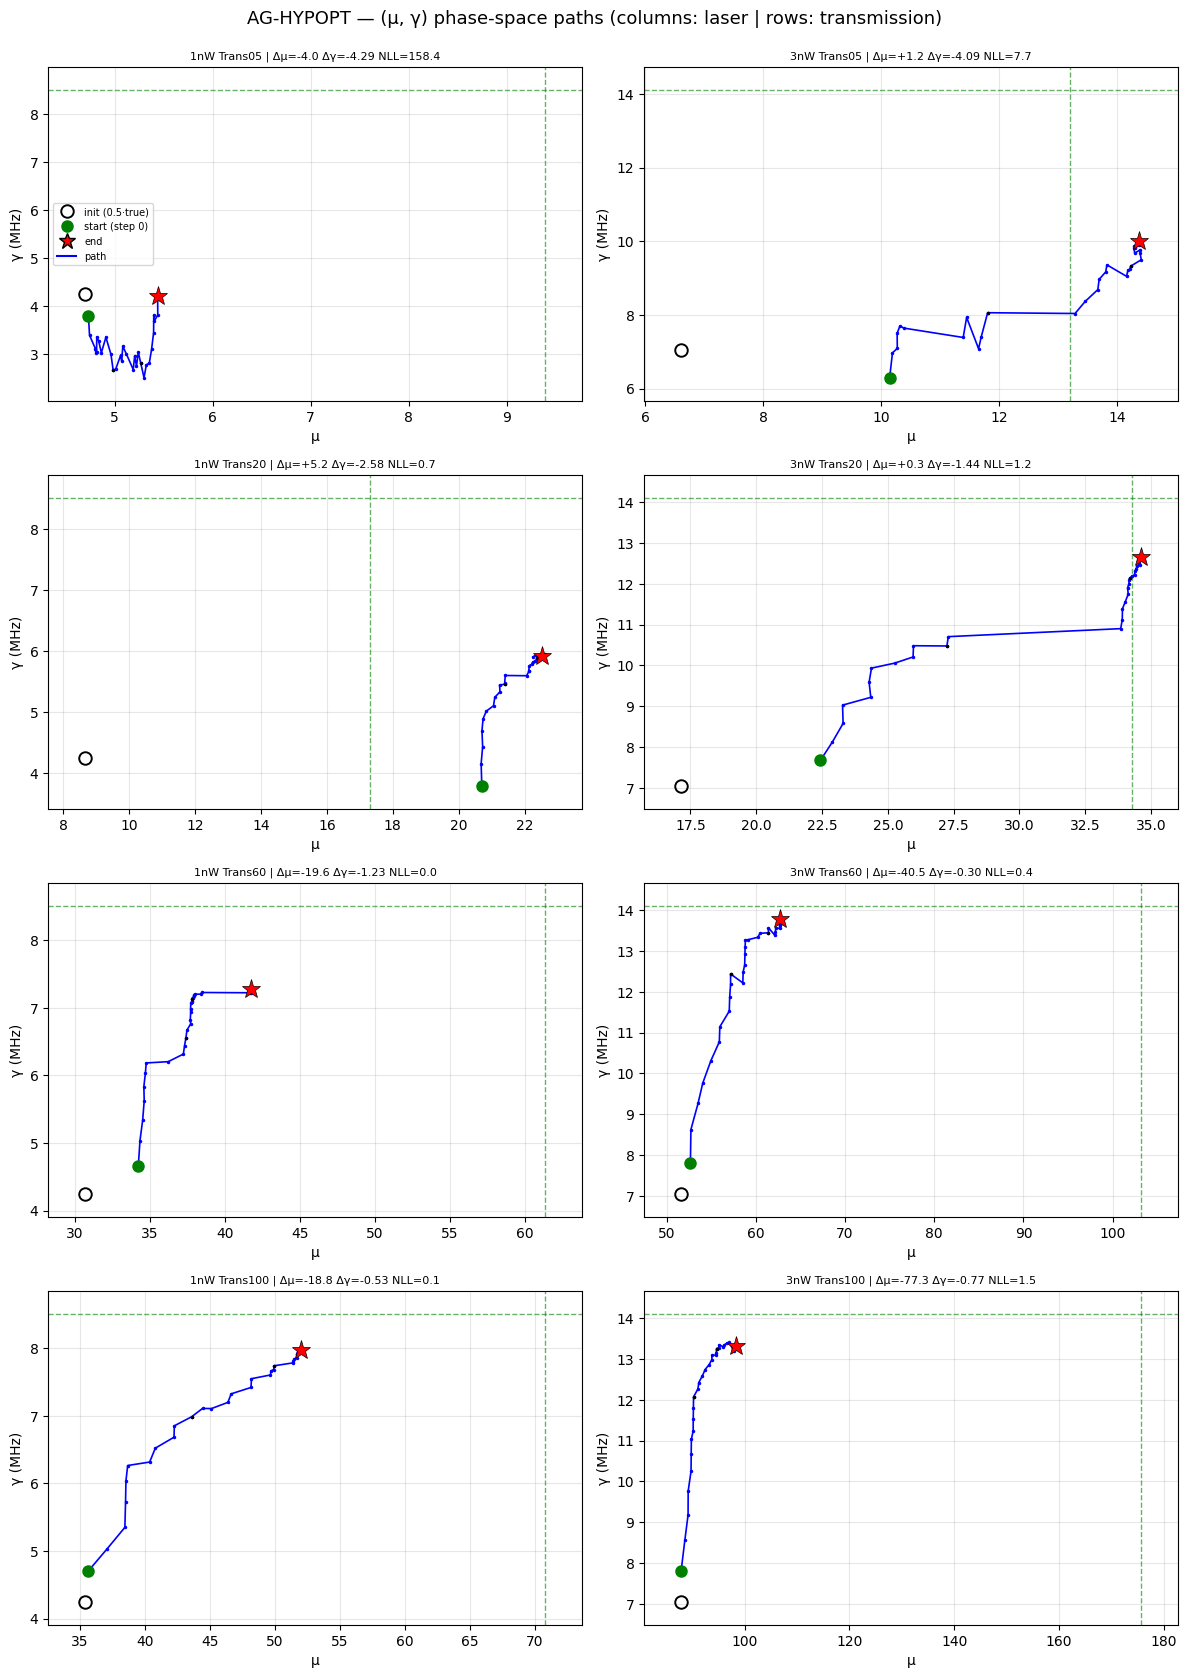

trial finished in 7.9 min
objective = 0.0725 ± 0.0201
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    5.44   -42.1 |     8.50    4.21   -50.4
1nW Trans20       17.32   22.52   +30.0 |     8.50    5.92   -30.4
1nW Trans60       61.37   41.78   -31.9 |     8.50    7.27   -14.4
1nW Trans100       70.82   52.05   -26.5 |     8.50    7.97    -6.2
3nW Trans05       13.20   14.37    +8.9 |    14.10   10.01   -29.0
3nW Trans20       34.28   34.63    +1.0 |    14.10   12.66   -10.2
3nW Trans60      103.20   62.75   -39.2 |    14.10   13.80    -2.2
3nW Trans100      175.71   98.45   -44.0 |    14.10   13.33    -5.5

weighted objective (T-graded, cap=1.0) = 0.0725 | diverged cells: 0
μ: RMSE 32.377 (rel 31.5%, bias -19.164) | γ: RMSE 2.406 (rel 24.2%, bias -1.904)


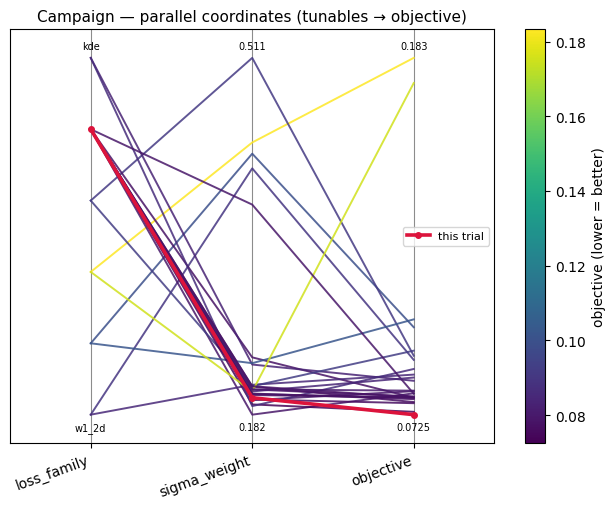

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

**Facts.** Chosen config `{loss_family: 'cvm_fwhm', sigma_weight: 0.1972}` (candidate 6, top EI).
Trial time 7.9 min, objective **0.0725 +/- 0.0201**, **0 diverged cells**. A **new campaign best**,
beating trial_13 (0.0733 at sw 0.1910) and now ~0.008 under the KDE control (0.080328).

**Basin statistics.** Fifteen `cvm_fwhm` points (sw 0.18-0.38): now 0.0725, 0.0733, 0.0760, 0.0764,
0.0773, 0.0777, 0.0778, 0.0778, 0.0781, 0.0790, 0.0791, 0.0798, 0.0799, 0.0840 (plus one earlier 0.0777)
-> mean ~0.0776, std ~0.003, fourteen of fifteen under the control. The best draws cluster at sw ~0.19-0.20.

**Per-cell behaviour / aggregates.** Unchanged; mu RMSE 32.38 (rel 31.5 %, bias -19.16), gamma RMSE 2.41
(rel 24.2 %, bias -1.90).

**Summary:** `cvm_fwhm` at sw 0.1972 sets a new campaign best of 0.0725, ~0.008 under the KDE control,
further confirming the sw ~0.19-0.20 basin.
**Key insight:** The `cvm_fwhm` basin floor is ~0.072-0.073 near sw 0.19-0.20, with a stable mean
~0.0776 over fifteen draws - a small but consistent winner over the control.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
[Notes for Anuar: none - loss-FORM comparison inside the pre-authorized knob.]


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'cvm_fwhm at sigma_weight 0.1972 sets a new campaign best of 0.0725, ~0.008 under the KDE control, further confirming the sw ~0.19-0.20 basin.'      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = 'The cvm_fwhm basin floor is ~0.072-0.073 near sw 0.19-0.20, with a stable mean ~0.0776 over fifteen draws - a small but consistent winner over the control.'  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_25 | current best: trial_25


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_26.ipynb. Open it and follow its cells from the top.
